In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [3]:

# Generate synthetic data with trend, seasonality, lags, and anomalies
np.random.seed(42)
n_points = 1000
t = np.arange(n_points)
trend = 0.05 * t
seasonality = 10 * np.sin(2 * np.pi * t / 365)
noise = np.random.normal(0, 1, size=n_points)
data = trend + seasonality + noise

# Add lag structure (autoregressive process)
lag = 10
for i in range(lag, n_points):
    data[i] += 0.5 * data[i - lag]

# Add anomalies (spikes/drops)
num_anomalies = 20
anomaly_indices = np.random.choice(range(n_points), num_anomalies, replace=False)
for idx in anomaly_indices:
    anomaly_type = np.random.choice(['spike', 'drop'])
    if anomaly_type == 'spike':
        data[idx] += np.random.uniform(30, 150)
    else:
        data[idx] -= np.random.uniform(30, 150)

# Add a lag-break anomaly (a sudden spike)
anomaly_point = np.random.randint(300, 700)
data[anomaly_point:] += np.random.uniform(50, 100, size=n_points - anomaly_point)

# Create DataFrame
df = pd.DataFrame({'timestamp': pd.date_range(start='2020-01-01', periods=n_points, freq='D'),
                   'value': data})


In [4]:

# ADF stands for Augmented Dickey Fuller Test for Stationarity
adf_result = adfuller(df['value'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
if adf_result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary. Differencing might be required.")


ADF Statistic: -1.3840594268117707
p-value: 0.5898939234402496
The time series is not stationary. Differencing might be required.


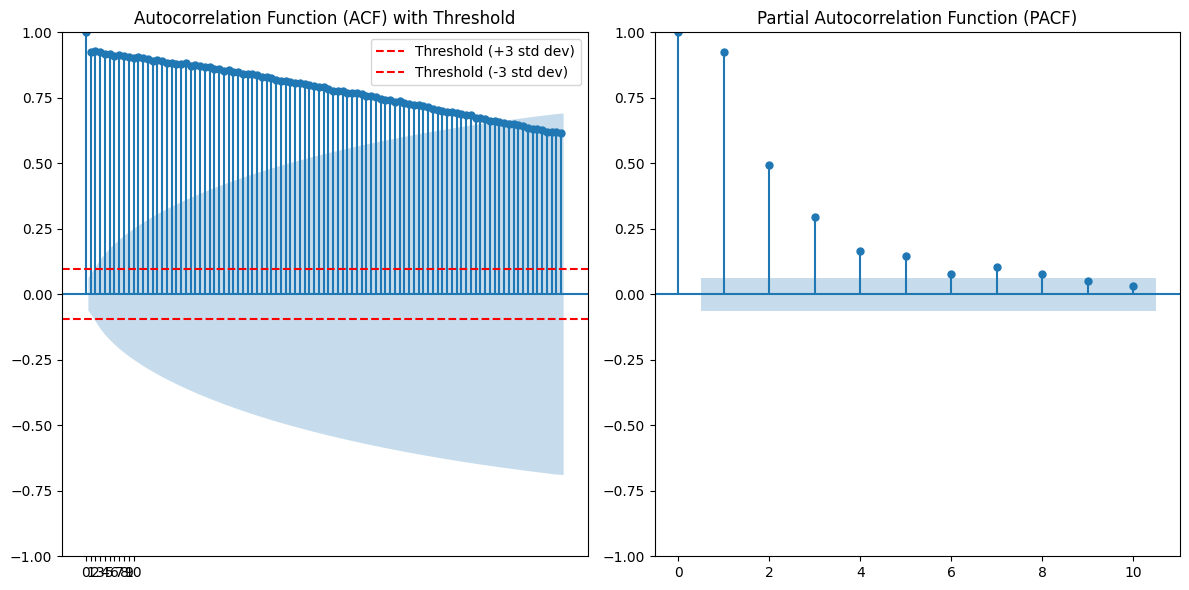

In [5]:

# Plot ACF and PACF to help determine ARIMA parameters (focus on first 10 lags)
plt.figure(figsize=(12, 6))

# ACF Plot focusing on the relevant area (showing threshold at 3 standard deviations)
plt.subplot(121)
plot_acf(df['value'], lags=100, ax=plt.gca())  # Set lags to 10
plt.axhline(y=3/np.sqrt(len(df['value'])), color='r', linestyle='--', label="Threshold (+3 std dev)")
plt.axhline(y=-3/np.sqrt(len(df['value'])), color='r', linestyle='--', label="Threshold (-3 std dev)")
plt.title('Autocorrelation Function (ACF) with Threshold')

# Set x-ticks to be integers (from 0 to 10)
plt.xticks(np.arange(0, 11, 1))  # Set the x-ticks to be integers

plt.legend()

# PACF Plot (focus on first 10 lags)
plt.subplot(122)
plot_pacf(df['value'], lags=10, ax=plt.gca())  # Set lags to 10
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()




c:\Users\cleme\code\SEAS6414\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\cleme\code\SEAS6414\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\cleme\code\SEAS6414\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


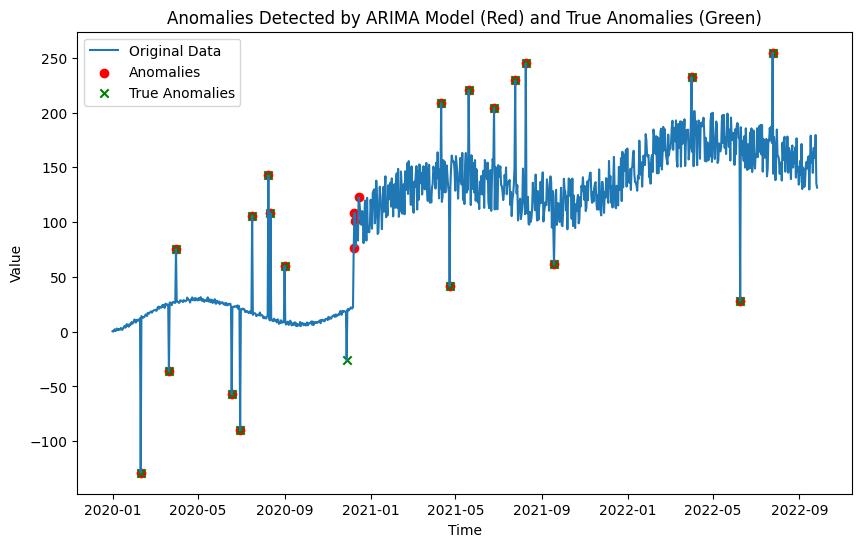

Anomalies detected at indices: [40, 80, 90, 169, 181, 198, 221, 224, 244, 342, 343, 344, 349, 466, 478, 505, 541, 571, 586, 626, 821, 890, 936]


In [13]:
# Fit ARIMA Model (p, d, q) where p and q are determined from PACF and ACF
# Based on ACF and PACF plots, let's assume p=9, d=2 (for differencing), q=0
model = ARIMA(df['value'], order=(9, 1, 10))
model_fit = model.fit()

# Anomaly Detection using ARIMA model
# Predicting the values
predictions = model_fit.predict(start=0, end=n_points-1)

# Calculate the residuals (difference between actual and predicted values)
residuals = df['value'] - predictions

# Anomalies are those where the residual is significantly different from 0 (thresholding)
threshold = 2.5 * np.std(residuals)  # 2.5 standard deviations as threshold
anomalies = residuals[abs(residuals) > threshold]

# Plot the time series and highlight anomalies
plt.figure(figsize=(10, 6))
plt.plot(df['timestamp'], df['value'], label='Original Data')

# Highlight anomalies with red dots
plt.scatter(df['timestamp'][anomalies.index], df['value'][anomalies.index], color='red', label='Anomalies')

# Highlight true anomalies (from synthetic data)
plt.scatter(df['timestamp'][anomaly_indices], df['value'][anomaly_indices], color='green', label='True Anomalies', marker='x')

plt.title('Anomalies Detected by ARIMA Model (Red) and True Anomalies (Green)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# Print anomalies
print(f"Anomalies detected at indices: {anomalies.index.tolist()}")

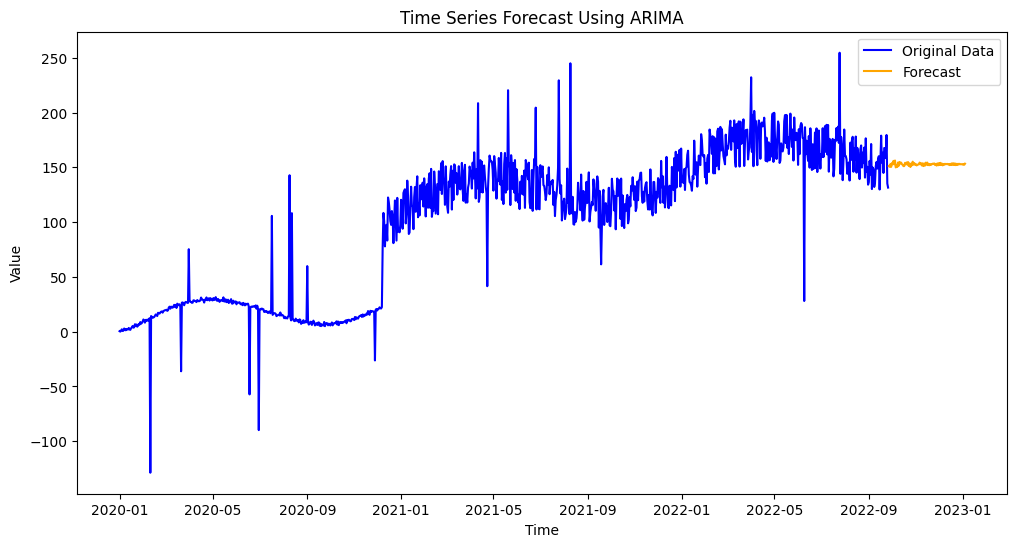

In [14]:
# Forecast future values
forecast_horizon = 100  # Number of days to forecast
forecast = model_fit.forecast(steps=forecast_horizon)
forecast_index = pd.date_range(start=df['timestamp'].iloc[-1] + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

# Plot original data and forecast
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['value'], label='Original Data', color='blue')
plt.plot(forecast_index, forecast, label='Forecast', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Time Series Forecast Using ARIMA')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate forecast on the last 100 days
train_data = df['value'][:-forecast_horizon]
test_data = df['value'][-forecast_horizon:]
model_past = ARIMA(train_data, order=(8, 1, 100))
model_past_fit = model_past.fit()
past_forecast = model_past_fit.forecast(steps=forecast_horizon)

# Calculate error metrics
mae = mean_absolute_error(test_data, past_forecast)
mse = mean_squared_error(test_data, past_forecast)
rmse = np.sqrt(mse)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot original data, test data, and past forecast
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['value'], label='Original Data', color='blue')
plt.plot(df['timestamp'][-forecast_horizon:], past_forecast, label='Past Forecast', color='red', linestyle='dashed')
plt.plot(forecast_index, forecast, label='Future Forecast', color='orange', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Time Series Forecast Using ARIMA')
plt.legend()
plt.show()

c:\Users\cleme\code\SEAS6414\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


KeyboardInterrupt: 

Normality Testing and DataSet Comparisson

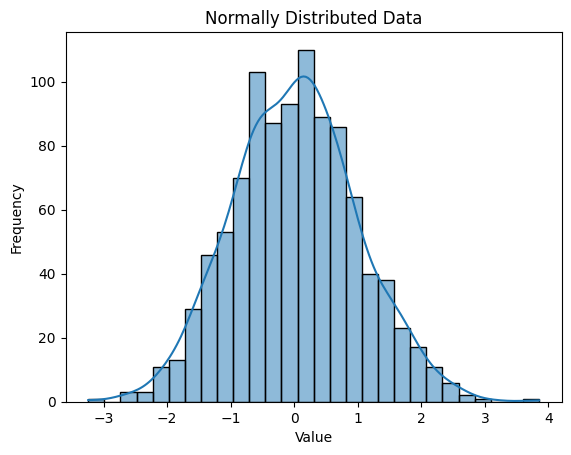

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate normal data
normal_data = np.random.normal(loc=0, scale=1, size=1000)

# Plot histogram
sns.histplot(normal_data, kde=True)
plt.title("Normally Distributed Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


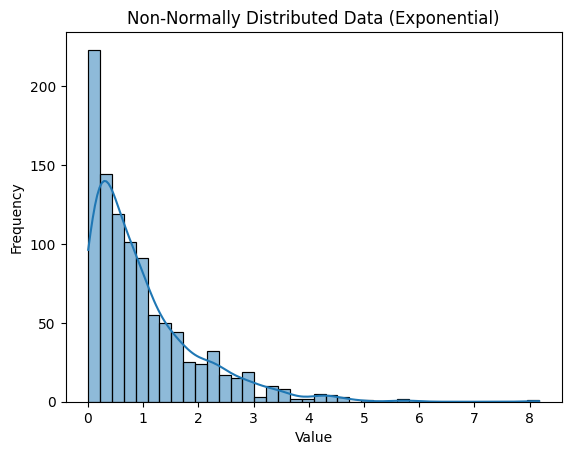

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
np.random.seed(42)

# Generate skewed (non-normal) data
non_normal_data = np.random.exponential(scale=1, size=1000)

# Plot histogram
sns.histplot(non_normal_data, kde=True)
plt.title("Non-Normally Distributed Data (Exponential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

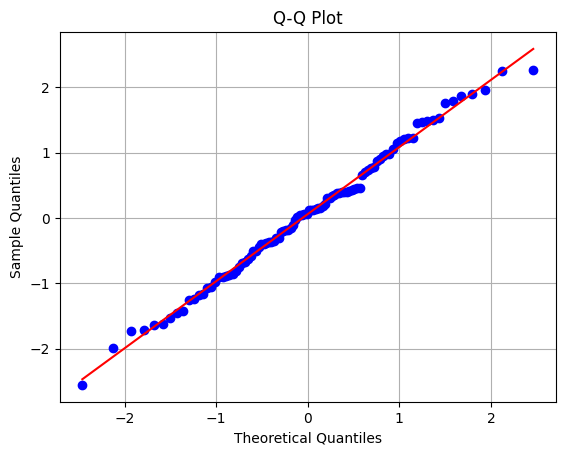

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate sample data (change to test different distributions)
np.random.seed(0)
data = np.random.standard_normal(loc=0, scale=1, size=100)  # Normal data
# data = np.random.exponential(scale=1, size=100)  # Uncomment for non-normal

# Create Q-Q plot
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()


In [10]:
from scipy.stats import shapiro

ALPHA = 0.05  # Significance level

stat, p = shapiro(non_normal_data)

# Show results
print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Interpretation
if p > ALPHA:
    print("Data looks normally distributed (fail to reject H0).")
else:
    print("Data is likely not normally distributed (reject H0).")

Shapiro-Wilk Test Statistic: 0.8246
P-value: 0.0000
Data is likely not normally distributed (reject H0).


In [7]:
from scipy.stats import anderson

result = anderson(normal_data, dist='norm')

# Show results
print(f"Anderson-Darling Test Statistic: {result.statistic:.4f}")
print("Critical Values and Significance Levels:")

for sl, cv in zip(result.significance_level, result.critical_values):
    print(f"  At {sl}% significance level: critical value = {cv:.4f}")

# Interpretation
for sl, cv in zip(result.significance_level, result.critical_values):
    if result.statistic < cv:
        print(f"Data looks normal at {sl}% level.")
    else:
        print(f"Data is not normal at {sl}% level.")


Anderson-Darling Test Statistic: 0.3475
Critical Values and Significance Levels:
  At 15.0% significance level: critical value = 0.5740
  At 10.0% significance level: critical value = 0.6530
  At 5.0% significance level: critical value = 0.7840
  At 2.5% significance level: critical value = 0.9140
  At 1.0% significance level: critical value = 1.0880
Data looks normal at 15.0% level.
Data looks normal at 10.0% level.
Data looks normal at 5.0% level.
Data looks normal at 2.5% level.
Data looks normal at 1.0% level.


In [9]:
from scipy.stats import kstest

stat, p = kstest(normal_data, 'norm')  # Assumes mean=0, std=1 unless data is standardized


# Show results
print(f"Kolgomorov Test Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Interpretation
if p > ALPHA:
    print("Data looks normally distributed (fail to reject H0).")
else:
    print("Data is likely not normally distributed (reject H0).")

Kolgomorov Test Statistic: 0.0173
P-value: 0.9197
Data looks normally distributed (fail to reject H0).


Independent T-Test:  Assumes both sets are normal, with similar variance.

In [32]:
from scipy.stats import levene
import numpy as np

# Sample data
group1 = np.random.normal(50, 5, 30)
group2 = np.random.normal(50, 6, 30)  # larger variance here

# Levene's test
stat, p = levene(group1, group2)
print(f"Levene's test statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

if p > 0.05:
    print("Variances are equal (fail to reject H0).")
else:
    print("Variances are NOT equal (reject H0).")

Levene's test statistic: 1.4443
P-value: 0.2343
Variances are equal (fail to reject H0).


In [33]:
from scipy.stats import ttest_ind

# Student's t-test assuming equal variance
t_stat, p_value = ttest_ind(group1, group2, equal_var=True)

print(f"Student's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: significant difference between groups.") 
else:
    print("Fail to reject the null hypothesis: no significant difference between groups.")  


Student's t-test statistic: 0.0267
P-value: 0.9788
Fail to reject the null hypothesis: no significant difference between groups.


In [14]:
mean1 = group1.mean()
mean2 = group2.mean()

print(f"Mean of group 1: {mean1:.2f}")
print(f"Mean of group 2: {mean2:.2f}")

if mean1 > mean2:
    print("Group 1 has the larger mean.")
elif mean2 > mean1:
    print("Group 2 has the larger mean.")
else:
    print("Both groups have the same mean.")


Mean of group 1: 49.06
Mean of group 2: 51.39
Group 2 has the larger mean.


In [39]:
from scipy.stats import levene
import numpy as np

# Sample data
group1 = np.random.normal(50, 5, 30)
group2 = np.random.normal(55, 10, 30)  # larger variance here

# Levene's test
stat, p = levene(group1, group2)
print(f"Levene's test statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

if p > 0.05:
    print("Variances are equal (fail to reject H0).")
else:
    print("Variances are NOT equal (reject H0).")


Levene's test statistic: 12.9834
P-value: 0.0007
Variances are NOT equal (reject H0).


In [41]:
from scipy.stats import ttest_ind

# Perform Welch's t-test (equal_var=False)
t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference between group means (reject H0).")
else:
    print("No significant difference between group means (fail to reject H0).")


Welch's t-test statistic: -2.0282
P-value: 0.0489
Significant difference between group means (reject H0).


In [43]:
from scipy.stats import ttest_rel

# Sample paired data (e.g., before and after treatment)
before = np.array([70, 75, 80, 65, 90])
after = np.array([75, 78, 85, 70, 92])

# Perform paired t-test
t_stat, p_value = ttest_rel(after, before)

# Calculate means
mean_before = np.mean(before)
mean_after = np.mean(after)
mean_diff = np.mean(after - before)

print(f"Mean before: {mean_before:.2f}")
print(f"Mean after: {mean_after:.2f}")
print(f"Mean difference (after - before): {mean_diff:.2f}")

print(f"\nPaired t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of which is larger
if mean_after > mean_before:
    print("On average, 'after' values are larger than 'before' values.")
elif mean_after < mean_before:
    print("On average, 'before' values are larger than 'after' values.")
else:
    print("On average, 'before' and 'after' values are the same.")

# Statistical significance check
if p_value < 0.01:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")


Mean before: 76.00
Mean after: 80.00
Mean difference (after - before): 4.00

Paired t-test statistic: 6.3246
P-value: 0.0032
On average, 'after' values are larger than 'before' values.
The difference is statistically significant.


Shapiro-Wilk test on differences:
  W = 0.9317, p = 0.1661


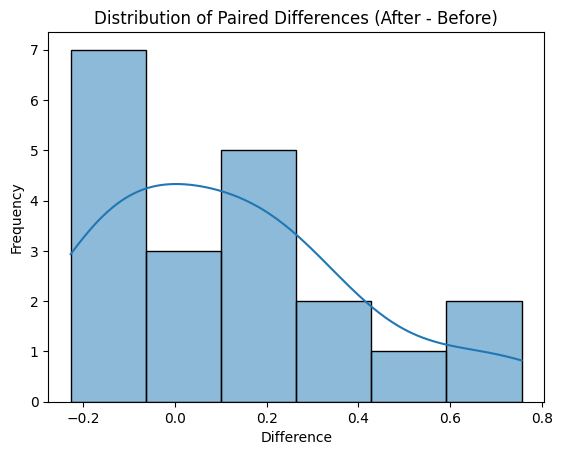

Differences are normally distributed. Use Paired t-test.
Paired t-test: t = 1.9201, p = 0.0700
No statistically significant difference.


In [22]:
import numpy as np
from scipy.stats import wilcoxon, ttest_rel, shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Generate non-normal data (e.g., exponential)
np.random.seed(42)
before = np.random.exponential(scale=1.0, size=20)
after  = before + np.random.normal(loc=0.2, scale=0.3, size=20)  # Add small shift

#  Normality test on differences
differences = after - before
stat, p_shapiro = shapiro(differences)
print(f"Shapiro-Wilk test on differences:")
print(f"  W = {stat:.4f}, p = {p_shapiro:.4f}")

# Plot distribution of differences
sns.histplot(differences, kde=True)
plt.title("Distribution of Paired Differences (After - Before)")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

# Choose appropriate test based on normality
if p_shapiro < 0.05:
    print("Differences are not normally distributed. Use Wilcoxon test.")
    stat, p = wilcoxon(after, before)
    print(f"Wilcoxon signed-rank test: stat = {stat}, p = {p:.4f}")
else:
    print("Differences are normally distributed. Use Paired t-test.")
    stat, p = ttest_rel(after, before)
    print(f"Paired t-test: t = {stat:.4f}, p = {p:.4f}")

if p < 0.05:
    print("Statistically significant difference.")
else:
    print("No statistically significant difference.")


In [44]:
!pip install scikit-posthocs


Shapiro-Wilk Normality Test:
  Group A: p = 0.6868 → Normal
  Group B: p = 0.0005 → Not normal
  Group C: p = 0.2742 → Normal

 Not all groups are normal. Using Kruskal–Wallis test instead...
Kruskal–Wallis H-statistic: 61.2279
Kruskal–Wallis p-value: 0.0000

Post-hoc Dunn’s Test (Bonferroni-corrected p-values):
              A             B             C
A  1.000000e+00  6.517558e-09  5.085281e-01
B  6.517558e-09  1.000000e+00  5.594927e-13
C  5.085281e-01  5.594927e-13  1.000000e+00


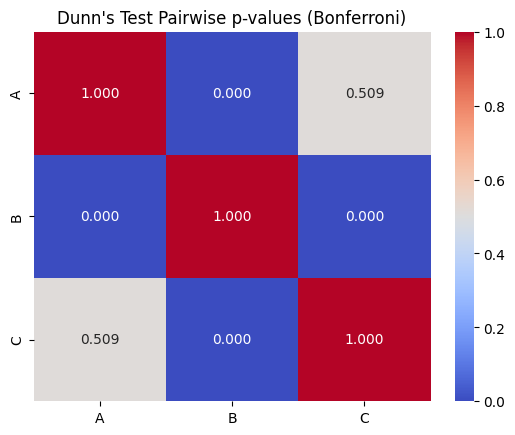

In [52]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, shapiro, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data: 3 groups with different means
np.random.seed(42)
group_A = np.random.normal(loc=50, scale=5, size=30)
# group_B = np.random.normal(loc=52, scale=5, size=30)
group_B = np.random.exponential(scale=3, size=30)  # Uncomment for non-normal
group_C = np.random.normal(loc=51, scale=5, size=30)

# Combine into a DataFrame
data = pd.DataFrame({
    'score': np.concatenate([group_A, group_B, group_C]),
    'group': ['A'] * 30 + ['B'] * 30 + ['C'] * 30
})

# Normality check per group
print("Shapiro-Wilk Normality Test:")
groups = ['A', 'B', 'C']
normal_flags = []
for g in groups:
    stat, p = shapiro(data[data['group'] == g]['score'])
    normal_flags.append(p > 0.05)
    print(f"  Group {g}: p = {p:.4f} → {'Normal' if p > 0.05 else 'Not normal'}")

# Use ANOVA if all groups are normal, otherwise Kruskal-Wallis
if all(normal_flags):
    print("\n All groups appear normal. Proceeding with one-way ANOVA...")
    f_stat, p_value = f_oneway(
        data[data['group'] == 'A']['score'],
        data[data['group'] == 'B']['score'],
        data[data['group'] == 'C']['score']
    )
    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_value:.4f}")

    # Post-hoc: Tukey’s HSD
    tukey = pairwise_tukeyhsd(endog=data['score'], groups=data['group'], alpha=0.05)
    print("\nTukey HSD Results:")
    print(tukey)

    # Plot Tukey intervals
    tukey.plot_simultaneous()
    plt.title("Tukey HSD Confidence Intervals")
    plt.show()

else:
    print("\n Not all groups are normal. Using Kruskal–Wallis test instead...")
    h_stat, p_value = kruskal(
        data[data['group'] == 'A']['score'],
        data[data['group'] == 'B']['score'],
        data[data['group'] == 'C']['score']
    )
    print(f"Kruskal–Wallis H-statistic: {h_stat:.4f}")
    print(f"Kruskal–Wallis p-value: {p_value:.4f}")

    # Post-hoc: Dunn’s test with Bonferroni correction
    dunn = sp.posthoc_dunn(data, val_col='score', group_col='group', p_adjust='bonferroni')
    print("\nPost-hoc Dunn’s Test (Bonferroni-corrected p-values):")
    print(dunn)

    # Heatmap of post-hoc p-values
    sns.heatmap(dunn, annot=True, cmap="coolwarm", fmt=".3f")
    plt.title("Dunn's Test Pairwise p-values (Bonferroni)")
    plt.show()


In [24]:
import numpy as np
import pandas as pd
from scipy.stats import (
    shapiro, levene, ttest_ind, ttest_rel,
    mannwhitneyu, wilcoxon, f_oneway,
    kruskal, friedmanchisquare
)

def compare_groups(*groups, paired=False, alpha=0.05):
    k = len(groups)

    # Convert to numpy arrays
    groups = [np.asarray(g) for g in groups]

    print(f"\n--- Statistical Test Selection ---")
    print(f"Number of groups: {k}")
    print(f"Paired: {paired}")
    
    if k < 2:
        print("Need at least two groups to compare.")
        return
    
    if paired:
        if k == 2:
            # Paired: check normality of differences
            differences = groups[1] - groups[0]
            stat, p = shapiro(differences)
            print(f"Shapiro-Wilk test on paired differences: p = {p:.4f}")
            if p > alpha:
                print("Differences are normal → Paired t-test")
                t_stat, p_val = ttest_rel(groups[1], groups[0])
                print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
            else:
                print("Differences are not normal → Wilcoxon signed-rank test")
                stat, p_val = wilcoxon(groups[1], groups[0])
                print(f"W = {stat:.4f}, p = {p_val:.4f}")
        elif k >= 3:
            # Repeated measures: check normality of differences?
            print("Friedman test used for 3+ paired groups (non-parametric)")
            stat, p_val = friedmanchisquare(*groups)
            print(f"Friedman test: χ² = {stat:.4f}, p = {p_val:.4f}")
        return

    # Unpaired groups
    normal_flags = []
    for i, g in enumerate(groups):
        stat, p = shapiro(g)
        print(f"Group {i+1} Shapiro-Wilk p = {p:.4f}")
        normal_flags.append(p > alpha)

    all_normal = all(normal_flags)

    if k == 2:
        if all_normal:
            # Check equal variance
            stat, p = levene(groups[0], groups[1])
            print(f"Levene's test for equal variances: p = {p:.4f}")
            if p > alpha:
                print("Equal variances → Student's t-test")
                t_stat, p_val = ttest_ind(groups[0], groups[1], equal_var=True)
                print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
            else:
                print("Unequal variances → Welch's t-test")
                t_stat, p_val = ttest_ind(groups[0], groups[1], equal_var=False)
                print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
        else:
            print("Non-normal distribution → Mann-Whitney U test")
            stat, p_val = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            print(f"U = {stat:.4f}, p = {p_val:.4f}")
    elif k >= 3:
        if all_normal:
            print("All groups normal → One-way ANOVA")
            stat, p_val = f_oneway(*groups)
            print(f"F = {stat:.4f}, p = {p_val:.4f}")
        else:
            print("Non-normal group(s) → Kruskal-Wallis test")
            stat, p_val = kruskal(*groups)
            print(f"H = {stat:.4f}, p = {p_val:.4f}")
